# Parte 5 — Bonus: LoRA sobre BERTweet
### Workshop: Clasificación de Emociones en Twitter

BERTweet tiene ~110M parámetros — el doble que DistilBERT. LoRA permite adaptarlo con una fracción mínima de los parámetros.

BERTweet usa la arquitectura de BERT, cuyas proyecciones de atención tienen nombres distintos a DistilBERT:

| Modelo | Proyecciones |
|---|---|
| DistilBERT | `q_lin`, `k_lin`, `v_lin`, `out_lin` |
| BERTweet / BERT | `query`, `key`, `value`, `dense` |

**Prerequisito:** haber ejecutado `part-1-data.ipynb` y `part-2-pipeline.ipynb`

In [1]:
import os, pathlib

# Ensure we run from the notebook's directory so relative %%run paths resolve
_nb_dir = pathlib.Path("/teamspace/studios/this_studio/deep-learning-mjbv-20261/Workshop 4 - NLP")
if not (_nb_dir / "tweeteval-part-2-pipeline.ipynb").exists():
    raise FileNotFoundError(f"Cannot find pipeline notebook in {_nb_dir}")
os.chdir(_nb_dir)

%run tweeteval-part-2-pipeline.ipynb

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/nbformat/__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 3257
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 1421
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 374
    })
})
compute_metrics OK
make_tokenized_dataset OK
full_evaluation OK
plot_training_curves OK
make_trainer OK

Pipeline lista. Puedes continuar con part-3-distilbert.ipynb


In [7]:
from peft import LoraConfig, get_peft_model, TaskType

MODEL_CHECKPOINT = "vinai/bertweet-base"
HF_REPO = "majonator/tweeteval-emotion-bertweet-lora"
LR_LORA = 2e-4   # más alto que full FT — pocos parámetros entrenables

## Dataset tokenizado

Reutilizamos el tokenizador de BERTweet del experimento anterior.

In [8]:
from transformers import AutoTokenizer

tok_bertweet = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT, normalization=True)
ds_bertweet = make_tokenized_dataset(tok_bertweet)
print(ds_bertweet)

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 3257
    })
    test: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 1421
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 374
    })
})


## Inspección de módulos

Antes de aplicar LoRA, inspeccionamos los nombres de las capas lineales de BERTweet.

In [9]:
from transformers import AutoModelForSequenceClassification

base_bt = AutoModelForSequenceClassification.from_pretrained(
    MODEL_CHECKPOINT, num_labels=NUM_LABELS,
    id2label=ID2LABEL, label2id=LABEL2ID)

print("Módulos lineales de BERTweet:")
for name, module in base_bt.named_modules():
    if isinstance(module, torch.nn.Linear):
        print(f"  {name}  [{module.in_features} → {module.out_features}]")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initi

Módulos lineales de BERTweet:
  roberta.encoder.layer.0.attention.self.query  [768 → 768]
  roberta.encoder.layer.0.attention.self.key  [768 → 768]
  roberta.encoder.layer.0.attention.self.value  [768 → 768]
  roberta.encoder.layer.0.attention.output.dense  [768 → 768]
  roberta.encoder.layer.0.intermediate.dense  [768 → 3072]
  roberta.encoder.layer.0.output.dense  [3072 → 768]
  roberta.encoder.layer.1.attention.self.query  [768 → 768]
  roberta.encoder.layer.1.attention.self.key  [768 → 768]
  roberta.encoder.layer.1.attention.self.value  [768 → 768]
  roberta.encoder.layer.1.attention.output.dense  [768 → 768]
  roberta.encoder.layer.1.intermediate.dense  [768 → 3072]
  roberta.encoder.layer.1.output.dense  [3072 → 768]
  roberta.encoder.layer.2.attention.self.query  [768 → 768]
  roberta.encoder.layer.2.attention.self.key  [768 → 768]
  roberta.encoder.layer.2.attention.self.value  [768 → 768]
  roberta.encoder.layer.2.attention.output.dense  [768 → 768]
  roberta.encoder.layer.2.

### 📝 TODO 5.1 — Configurar y aplicar LoRA a BERTweet

In [10]:
# TODO 5.1 ── LoRA sobre BERTweet
# ─────────────────────────────────────────────────────────────────────────────
# Los nombres de las proyecciones de atención de BERTweet (BERT-base) son:
#   bert.encoder.layer.X.attention.self.query  → target 'query'
#   bert.encoder.layer.X.attention.self.value  → target 'value'
# La cabeza clasificadora (modules_to_save) es 'classifier'
lora_config = LoraConfig(
    task_type = TaskType.SEQ_CLS,
    r = 8,
    lora_alpha = 16,
    lora_dropout = 0.1,
    target_modules = ["query", "value"],
    modules_to_save = ["classifier"],
)

model_bertweet_lora = get_peft_model(base_bt, lora_config)
model_bertweet_lora.print_trainable_parameters()

trainable params: 888,580 || all params: 135,791,624 || trainable%: 0.6544


### 📝 TODO 5.2 — Entrenar BERTweet-LoRA

In [11]:
# TODO 5.2 ── Entrenar BERTweet-LoRA
# ─────────────────────────────────────────────────────────────────────────────
trainer_lora = make_trainer(
    model = model_bertweet_lora,
    tokenizer = tok_bertweet,
    tokenized_ds = ds_bertweet,
    output_dir = "./checkpoints/bertweet-lora",
    lr = LR_LORA,
)
trainer_lora.train()

`use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss,F1 Macro,Accuracy
1,0.988352,0.876743,0.540348,0.697861
2,0.554326,0.595586,0.698732,0.775401
3,0.508308,0.524238,0.741400,0.804813
4,0.528281,0.503321,0.731979,0.796791
5,0.441224,0.501039,0.729338,0.791444


TrainOutput(global_step=510, training_loss=0.6786545912424723, metrics={'train_runtime': 32.1576, 'train_samples_per_second': 506.412, 'train_steps_per_second': 15.859, 'total_flos': 331052413876992.0, 'train_loss': 0.6786545912424723, 'epoch': 5.0})

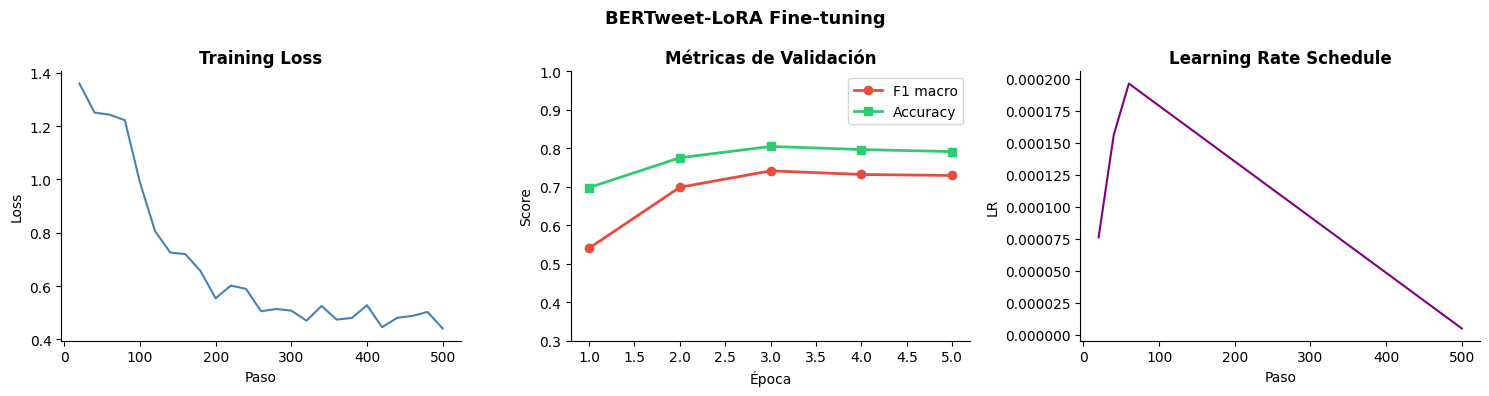

In [12]:
plot_training_curves(trainer_lora, title="BERTweet-LoRA Fine-tuning")


  Test — BERTweet-LoRA
              precision    recall  f1-score   support

       anger     0.8512    0.8817    0.8662       558
         joy     0.8523    0.8380    0.8451       358
    optimism     0.8250    0.5366    0.6502       123
     sadness     0.7640    0.8220    0.7919       382

    accuracy                         0.8248      1421
   macro avg     0.8231    0.7696    0.7884      1421
weighted avg     0.8258    0.8248    0.8222      1421



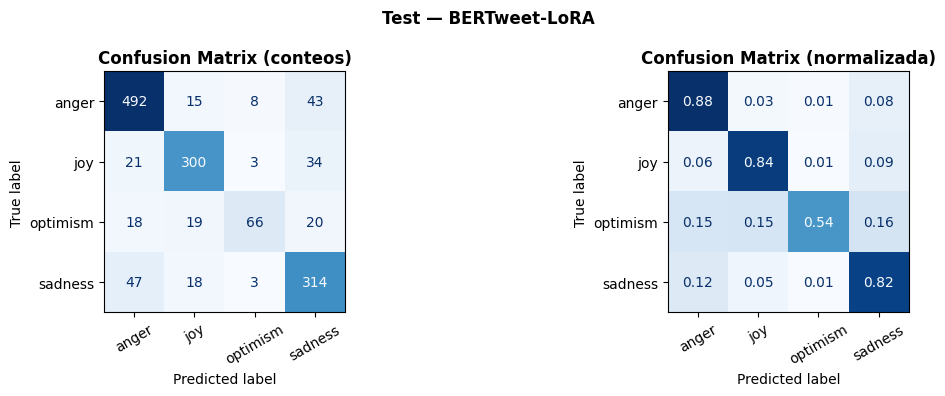

In [13]:
metrics_bertweet_lora = full_evaluation(trainer_lora, ds_bertweet["test"],
                                        model_name="BERTweet-LoRA")

## Push to Hub

Para subir el modelo LoRA al Hub necesitamos fusionarlo primero (`merge_and_unload`), que aplica $W' = W + BA$ y devuelve un modelo estándar sin overhead PEFT.

In [14]:
merged = model_bertweet_lora.merge_and_unload()
merged.push_to_hub(HF_REPO, commit_message="BERTweet LoRA r=8 — merged")
tok_bertweet.push_to_hub(HF_REPO)
print(f"Modelo publicado en: https://huggingface.co/{HF_REPO}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

README.md: 0.00B [00:00, ?B/s]

Modelo publicado en: https://huggingface.co/majonator/tweeteval-emotion-bertweet-lora
